<a href="https://colab.research.google.com/github/roughhawkbit/digi-inno-road-prod/blob/main/analysis/DataCharacterisationForPaper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
import math
import matplotlib
import numpy
import os
import pandas
import scipy
import sys

In [3]:
if IN_COLAB:
  dirpath = '/content/digi-inno-road-prod'
  if not os.path.isdir(dirpath):
    # TODO git pull
    !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git
  sys.path.insert(0,dirpath)
else:
  module_path = os.path.abspath(os.path.join('..'))
  if not module_path in sys.path:
      sys.path.insert(0, module_path)

from innoprod.digital_readiness_score import DRS_LEVELS
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.text_analysis.chunking_tools import chunk_text_sentencewise
from innoprod.wrangling.msyh_data_sharing import wrangle_roadmaps, wrangle_grants
from innoprod.wrangling.wrangling_tools import is_non_empty

Cloning into 'digi-inno-road-prod'...
remote: Enumerating objects: 693, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 693 (delta 71), reused 14 (delta 7), pack-reused 584 (from 1)
Receiving objects: 100% (693/693), 1.85 MiB | 12.04 MiB/s, done.
Resolving deltas: 100% (436/436), done.


In [4]:
data = get_sheet_dfs()
# Comment out the line below to explore only the initial dataset (i.e., firms what applied for at least one grant)
roadmaps_df = pandas.concat([data['Roadmaps'], data['RoadmapsWithoutGrants']])
roadmaps_df = wrangle_roadmaps(roadmaps_df)
grants_df = wrangle_grants(data['Grants'])

/content/digi-inno-road-prod/innoprod/wrangling/wrangling_tools.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series.loc[mask] = new_value


# Digital Readiness Score

In [5]:
drs_col_name = 'Current Digital Readiness Score (refer to PAS:1040)'

DRS values were specified for this many firms:

In [6]:
int(roadmaps_df[drs_col_name].notna().sum())

472

The mean DRS score:

In [7]:
float(roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name].mean())

4.440677966101695

And the standard deviation:

In [8]:
float(roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name].std())

1.6332135120381948

Grouping these by DRS score:

In [9]:
roadmaps_df[drs_col_name].value_counts().sort_index()

,count
Current Digital Readiness Score (refer to PAS:1040),
1,19
2,45
3,66
4,100
5,121
6,79
7,28
8,12
9,2


<Axes: xlabel='Digital Readiness Score', ylabel='Number of firms'>

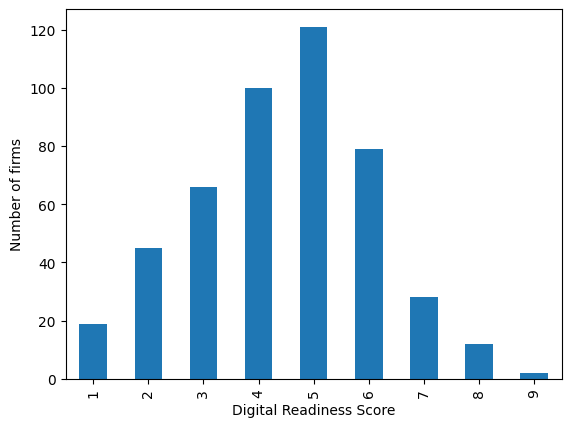

In [10]:
ax = roadmaps_df[drs_col_name].value_counts().sort_index().plot.bar()
ax.set_ylabel('Number of firms')
ax.set_xlabel('Digital Readiness Score')
ax

## Attempting to fit the data to a binomial distrbution

In [11]:
res = scipy.stats.fit(
    scipy.stats.binom,
    roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name],
    bounds={"n": [1,9]}
)
res.params

FitParams(n=np.float64(9.0), p=np.float64(0.49340865715380666), loc=np.float64(0.0))

In [12]:
# res.plot()

In [13]:
nllf = res.nllf()
math.exp(-nllf)

0.0

## Attempting to fit to a normal distribution

In [14]:
mu, sigma = scipy.stats.norm.fit(roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name])
print(f'mu={mu}, sigma={sigma}')

mu=4.440677966101695, sigma=1.6314824956407912


In [15]:
res = scipy.stats.norm.fit(
    roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name]
)
res

(np.float64(4.440677966101695), np.float64(1.6314824956407912))

In [16]:
gof = scipy.stats.goodness_of_fit(
    scipy.stats.norm,
    roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name],
)
gof.pvalue

np.float64(0.0001)

In [17]:
scipy.stats.skewtest(roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name])

SkewtestResult(statistic=np.float64(-0.4974866547075128), pvalue=np.float64(0.6188459114978442))

In [18]:
scipy.stats.kurtosistest(roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name])

KurtosistestResult(statistic=np.float64(-1.448362418021793), pvalue=np.float64(0.14751571957562343))

## DRS vs Digital Champion

In [19]:
champion_col = 'Do you have a Digital Champion in place?'
roadmaps_df[champion_col].value_counts(dropna=False)

,count
Do you have a Digital Champion in place?,
NaN,342
True,261
False,218


Text(0.5, 0, 'Expert-assigned DRS')

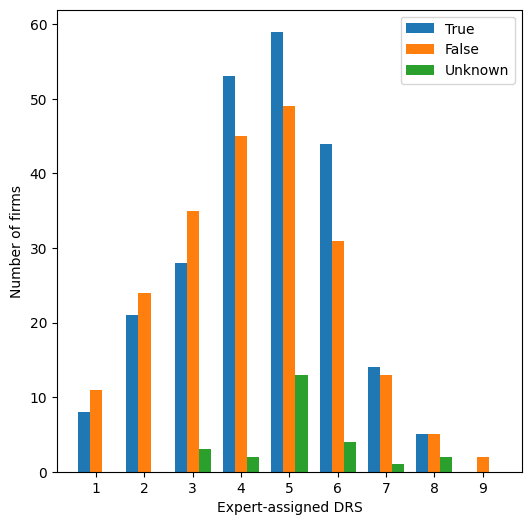

In [20]:
n_categories = len(roadmaps_df[champion_col].unique())
x = numpy.arange(1, len(DRS_LEVELS)+1)
width = 1/(n_categories+1)

fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

multiplier = -1

for champ in [True, False]:
  offset = width * multiplier
  y = roadmaps_df[roadmaps_df[champion_col] == champ].groupby(drs_col_name).size()
  y = y.reindex(range(1, len(DRS_LEVELS)+1), fill_value=0)
  rects = ax.bar(
      x + offset,
      y,
      width,
      label=champ
  )
  multiplier += 1

offset = width * multiplier
y = roadmaps_df[roadmaps_df[champion_col].isna()].groupby(drs_col_name).size()
y = y.reindex(range(1, len(DRS_LEVELS)+1), fill_value=0)
rects = ax.bar(
    x + offset,
    y,
    width,
    label=champ
)
rects.set_label('Unknown')

ax.set_xticks(x)

ax.legend()

ax.set_ylabel('Number of firms')
ax.set_xlabel('Expert-assigned DRS')

# Text

In [21]:
qual_cols = [
    'Summary review of Edge Digital diagnostic report & current state and key improvement areas',
    'What are the internal barriers to growth? How do you intend to finance future growth? Are there sufficient leadership and management skills in the business to achieve your growth? What opportunities do you have to expand into new markets?',
    'Details of any existing Digital Strategy', # Check: Rob added in on 21st May
    'Level of current Strategic Digital Skills/knowledge in the business',
    'Level of current Technical Digital Skills/knowledge in the business',
    'Whether the business is already investing/adopting/utilising Industry 4.0 Technologies, with examples',
    'Summary of the identified problems, including Gap Analysis'
]

short_labels = [
    "1. Edge Digital",
    "2. Investment barriers",
    "3. Existing strategy",
    "4. Strategic skills",
    "5. Technical skills",
    "6. Already investing?",
    "7. Identified problems"
]

Text(0, 0.5, 'Word count')

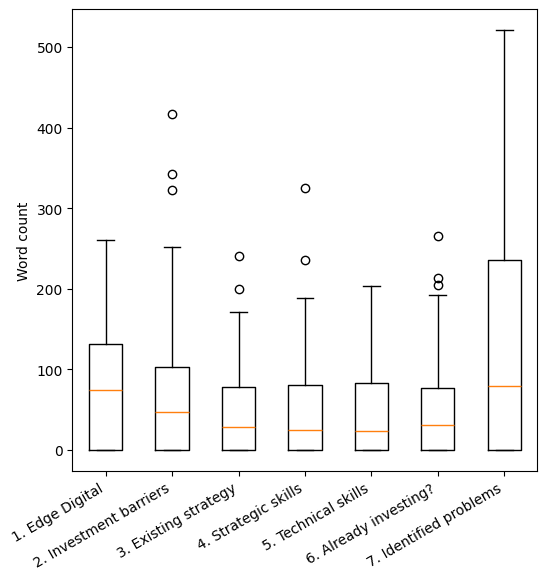

In [22]:
box_data = []
for i, col in enumerate(qual_cols):
  box_data.append(roadmaps_df[col].apply(lambda x: len(str(x).split())).to_numpy())

fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.boxplot(box_data)
ax.set_xticklabels(short_labels, rotation=30, ha="right")
ax.set_ylabel('Word count')

In [23]:
roadmaps_df['Summary of the identified problems, including Gap Analysis'].apply(lambda x: len(str(x).split())).max()

521

In [24]:
roadmaps_df['Summary of the identified problems, including Gap Analysis'].apply(lambda x: len(str(x).split())>500).value_counts()

,count
"Summary of the identified problems, including Gap Analysis",
False,820
True,1


In [53]:
qual_df = roadmaps_df[['Client ID', 'Current Digital Readiness Score (refer to PAS:1040)'] + qual_cols].copy()
# qual_df = qual_df[roadmaps_df[drs_col_name].notna()]
qual_df['Context'] = roadmaps_df.apply(lambda row: ' '.join(filter(None, [row[c] for c in qual_cols])), axis=1)
qual_df.drop(qual_cols, axis=1, inplace=True)
qual_df["Word Count"] = qual_df["Context"].apply(lambda x: len(str(x).split()))
qual_df

,Client ID,Current Digital Readiness Score (refer to PAS:1040),Context,Word Count
0,65CE53AE-8233-D485-957C-705AF17CCE77,4,Based on the output from the self completed [R...,1069
1,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,6,The business scored 6 on their self assessed E...,833
2,eb08ecff-5bf9-e60a-9cbf-66e8050adf5a,3,[REDACTED] Score: 3 STATUS: Based on the respo...,585
3,0C163899-5F59-970B-1033-ADCCE41DB525,5,"The company have completed [REDACTED], and bas...",958
4,C713DA4C-F07B-F227-351A-5C376EC69358,5,The EDD correctly identifies that [REDACTED]ha...,621
...,...,...,...,...
596,2161fb0b-6e89-910b-d9c3-6756d6b4c135,5,"The EDD recognises that, based on [REDACTED]'s...",565
597,6F89F3BF-426F-72F9-F0B4-A0F8791153EC,<NA>,,0
598,074E5951-6230-8FF3-C35E-62D137B2F3D1,<NA>,,0
599,E813515D-FD4F-9606-7506-9B51B1EB45E4,<NA>,,0


/tmp/ipykernel_9410/1277527442.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bins, rotation=30)


[Text(0, 0, '0-127'),
 Text(1, 0, '128-255'),
 Text(2, 0, '256-383'),
 Text(3, 0, '384-511'),
 Text(4, 0, '512-639'),
 Text(5, 0, '640-767'),
 Text(6, 0, '768-895'),
 Text(7, 0, '896-1023')]

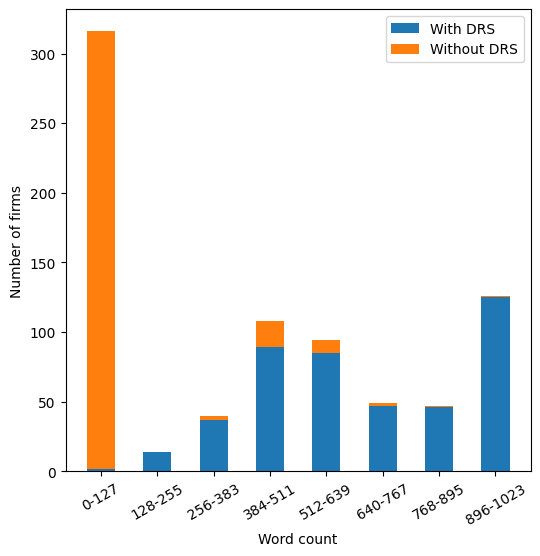

In [54]:
step = 128
n_bins = 8
bins = []
weight_counts = {
    "With DRS": numpy.zeros(n_bins),
    "Without DRS": numpy.zeros(n_bins)
}

for i in range(0, n_bins*step, step):
  bins.append(f"{i}-{i+step-1}")
  weight_counts["With DRS"][int(i/step)] = qual_df[
      qual_df[drs_col_name].notna() &
      (qual_df['Word Count'] >= i) &
      (qual_df['Word Count'] < i+step)
    ]['Word Count'].count()
  weight_counts["Without DRS"][int(i/step)] = qual_df[
      qual_df[drs_col_name].isna() &
      (qual_df['Word Count'] >= i) &
      (qual_df['Word Count'] < i+step)
    ]['Word Count'].count()

bottom = numpy.zeros(len(bins))
width = 0.5
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

for drs_label, weight_count in weight_counts.items():
    p = ax.bar(bins, weight_count, width, label=drs_label, bottom=bottom)
    bottom += weight_count

ax.set_ylabel('Number of firms')
ax.set_xlabel('Word count')
ax.legend()
ax.set_xticklabels(bins, rotation=30)


Chunk the text that is longer than 510 words sentencewise, and see if this can split the longest text blocks into just two.

In [55]:
has_text_mask = is_non_empty(qual_df['Context'])
qual_df['Chunked Text'] = qual_df['Context'].apply(lambda x: [] if x == '' else chunk_text_sentencewise(x, 510))
qual_df['N chunks'] = qual_df['Chunked Text'].apply(len)
qual_df['N chunks'].value_counts().sort_index()

,count
N chunks,
0,304
1,169
2,299
3,49


<Axes: xlabel='Current Digital Readiness Score (refer to PAS:1040)', ylabel='Word Count'>

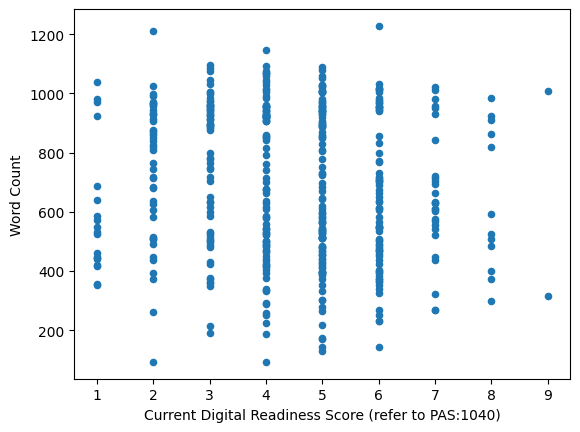

In [57]:
qual_df.plot.scatter(drs_col_name, 'Word Count')